In [1]:
import pandas as pd
import numpy as np

print("✔ Libraries loaded!")
base = r"C:\Users\Shyam\Documents\Python\VS code and SQL\Marketing Campaign Analysis System"

nykaa    = pd.read_csv(base + r"\nykaa_campaign_data_with_nulls.csv",      encoding="latin-1")
purplle   = pd.read_csv(base + r"\purplle_campaign_data_with_nulls.csv",        encoding="latin-1")
tira     = pd.read_csv(base + r"\tira_campaign_data_with_nulls.csv",         encoding="latin-1")

print("✔ All 3 files loaded!")

✔ Libraries loaded!
✔ All 3 files loaded!


In [2]:
print(f"nykaa   : {nykaa.shape}")
print(f"purplle : {purplle.shape}")
print(f"tira    : {tira.shape}")

nykaa   : (55555, 16)
purplle : (55555, 16)
tira    : (55555, 16)


In [3]:
nykaa['Brand'] = 'Nykaa'
purplle['Brand'] = 'Purplle'
tira['Brand'] = 'Tira'

In [4]:
df = pd.concat([nykaa, purplle, tira], ignore_index=True)

# Confirm it worked
print(df.shape)
print(df['Brand'].value_counts())

(166665, 17)
Brand
Nykaa      55555
Purplle    55555
Tira       55555
Name: count, dtype: int64


In [5]:
# Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166665 entries, 0 to 166664
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       161248 non-null  str    
 1   Campaign_Type     158307 non-null  str    
 2   Target_Audience   158493 non-null  str    
 3   Duration          158342 non-null  float64
 4   Channel_Used      158383 non-null  str    
 5   Impressions       158441 non-null  float64
 6   Clicks            158441 non-null  float64
 7   Leads             158575 non-null  float64
 8   Conversions       158665 non-null  float64
 9   Revenue           158361 non-null  float64
 10  Acquisition_Cost  158504 non-null  float64
 11  ROI               158367 non-null  float64
 12  Language          158366 non-null  str    
 13  Engagement_Score  158584 non-null  float64
 14  Customer_Segment  158490 non-null  str    
 15  Date              158566 non-null  str    
 16  Brand             166665 non-nu

In [6]:
# Missing values
df.isnull().sum()


Campaign_ID         5417
Campaign_Type       8358
Target_Audience     8172
Duration            8323
Channel_Used        8282
Impressions         8224
Clicks              8224
Leads               8090
Conversions         8000
Revenue             8304
Acquisition_Cost    8161
ROI                 8298
Language            8299
Engagement_Score    8081
Customer_Segment    8175
Date                8099
Brand                  0
dtype: int64

In [7]:
# Duplicates
df.duplicated().sum()


np.int64(0)

In [8]:
# Numerical columns — fill with median (excluding Acquisition_Cost and Revenue)
numerical_cols = ['Duration', 'Impressions', 'Clicks', 'Leads', 
                  'Conversions', 'Engagement_Score']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Acquisition_Cost — fill with mean
df['Acquisition_Cost'] = df['Acquisition_Cost'].fillna(df['Acquisition_Cost'].mean())

# Revenue — fill with 0 (no revenue recorded = 0)
df['Revenue'] = df['Revenue'].fillna(0)

# Categorical columns — fill with mode
categorical_cols = ['Campaign_Type', 'Target_Audience', 'Channel_Used', 
                    'Language', 'Customer_Segment']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Date — forward fill
df['Date'] = df['Date'].ffill()

# Drop Campaign_ID column — not needed for analysis
df = df.drop(columns=['Campaign_ID'])

# Verify
print(df.isnull().sum())
print("\nShape after dropping Campaign_ID:", df.shape)
print("\nColumns remaining:", df.columns.tolist())

Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Revenue                0
Acquisition_Cost       0
ROI                 8298
Language               0
Engagement_Score       0
Customer_Segment       0
Date                   0
Brand                  0
dtype: int64

Shape after dropping Campaign_ID: (166665, 16)

Columns remaining: ['Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Date', 'Brand']


In [9]:
df['ROI'] = (df['Revenue'] - df['Acquisition_Cost']) / df['Acquisition_Cost']
df['ROI'] = df['ROI'].replace([float('inf'), float('-inf')], 0)
df['ROI'] = df['ROI'].fillna(0)

# ✅ ROI is for EDA and display ONLY — never put it in reg_features
# ROI = f(Revenue) so it leaks the target into features

print("Min ROI  :", df['ROI'].min())
print("Max ROI  :", df['ROI'].max())
print("Mean ROI :", df['ROI'].mean())
print("Neg ROI  :", (df['ROI'] < 0).sum())
print("Null ROI :", df['ROI'].isnull().sum())

Min ROI  : -1.0
Max ROI  : 494114.4034229829
Mean ROI : 5878.534571622835
Neg ROI  : 8315
Null ROI : 0


In [10]:
# Check no nulls remain
print(df.isnull().sum())

# Compare original vs calculated ROI
print(df[['Revenue', 'Acquisition_Cost', 'Conversions', 
          'ROI']].head(10))

# Check ROI stats again
print("\nMin ROI:", df['ROI'].min())
print("Max ROI:", df['ROI'].max())
print("Mean ROI:", df['ROI'].mean())

Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
Brand               0
dtype: int64
     Revenue  Acquisition_Cost  Conversions           ROI
0  1867515.0         376.83056       2355.0   4954.848058
1  1046247.0         180.83000       1357.0   5784.804347
2   197055.0          90.60000        755.0   2174.000000
3   376906.0         249.07000        947.0   1512.253302
4   518296.0         228.60000       1258.0   2266.261592
5   877020.0         137.79000       1555.0   6363.903113
6   633402.0         210.17000       1386.0   3012.760289
7   326525.0         147.29000        925.0   2215.885057
8  1058665.0          87.74000       2551.0  12064.933440
9   603174.0         269.82000        858.0   2234.4680

In [11]:
# Tell pandas the format is Day-Month-Year
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Verify - should show no warning now
print(df['Date'].dtype)
print(df['Date'].head())

datetime64[us]
0   2025-04-29
1   2025-04-06
2   2025-01-14
3   2025-06-04
4   2024-12-29
Name: Date, dtype: datetime64[us]


In [12]:
# Fix Duration to integer
df['Duration'] = df['Duration'].astype(int)
print("Duration dtype:", df['Duration'].dtype)

# Validate ROI
print("Min ROI:", df['ROI'].min())
print("Max ROI:", df['ROI'].max())
print("Mean ROI:", df['ROI'].mean())
print("Negative ROI count:", (df['ROI'] < 0).sum())

Duration dtype: int64
Min ROI: -1.0
Max ROI: 494114.4034229829
Mean ROI: 5878.534571622835
Negative ROI count: 8315


In [13]:
# Install scikit-learn
!pip install scikit-learn
!pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

# Step 1 — Split channels by comma into a list
df['Channel_List'] = df['Channel_Used'].apply(
    lambda x: [ch.strip() for ch in x.split(',')])
# Step 2 — See what channels exist
print(df['Channel_List'].explode().unique())

<ArrowStringArray>
['WhatsApp', 'YouTube', 'Google', 'Facebook', 'Instagram', 'Email']
Length: 6, dtype: str


In [15]:
# Step 3 — Apply MultiLabelBinarizer
mlb = MultiLabelBinarizer()

channel_encoded = pd.DataFrame(
    mlb.fit_transform(df['Channel_List']),
    columns=['C_U_' + ch.replace(' ', '_') for ch in mlb.classes_],
    index=df.index
)

# Step 4 — Add to main dataframe
df = pd.concat([df, channel_encoded], axis=1)

# Step 5 — Verify
print("New columns added:", channel_encoded.columns.tolist())
print(df.shape)
print(channel_encoded.head())

New columns added: ['C_U_Email', 'C_U_Facebook', 'C_U_Google', 'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube']
(166665, 23)
   C_U_Email  C_U_Facebook  C_U_Google  C_U_Instagram  C_U_WhatsApp  \
0          0             0           0              0             1   
1          0             0           0              0             0   
2          0             0           1              0             1   
3          0             1           0              1             0   
4          0             1           0              1             0   

   C_U_YouTube  
0            1  
1            1  
2            1  
3            1  
4            0  


In [16]:
pd.set_option("display.max_columns",None)

In [17]:
df['Profit_Flag'] = (df['ROI'] > 0).astype(int)
print(df['Profit_Flag'].value_counts())
print("\nProfit campaigns:", (df['Profit_Flag'] == 1).sum())
print("Loss campaigns:", (df['Profit_Flag'] == 0).sum())

Profit_Flag
1    158350
0      8315
Name: count, dtype: int64

Profit campaigns: 158350
Loss campaigns: 8315


In [18]:
# Save so you don't lose progress
df.to_csv('cleaned_marketing_data.csv', index=False)
print("✅ Saved successfully!")
print("Final shape:", df.shape)

✅ Saved successfully!
Final shape: (166665, 24)


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_marketing_data.csv')
print("✅ Data loaded!")
print("Shape:", df.shape)

✅ Data loaded!
Shape: (166665, 24)


     Brand        Revenue
0    Nykaa  489568.993196
1  Purplle  488025.934461
2     Tira  487081.724327


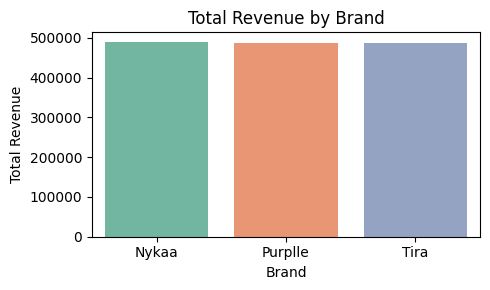

In [20]:
# Average revenue per campaign — better comparison!
brand_revenue = df.groupby('Brand')['Revenue'].mean().reset_index()
print(brand_revenue)
# Plot it
plt.figure(figsize=(5,3))       # Set chart size
sns.barplot(data=brand_revenue, 
            x='Brand',          # X axis = Brand names
            y='Revenue',        # Y axis = Total Revenue
            hue='Brand',        # ← Add this
            legend=False,
            palette='Set2')     # Color theme

plt.title('Total Revenue by Brand')  # Chart title
plt.ylabel('Total Revenue')
plt.xlabel('Brand')
plt.tight_layout()   # Prevents text from getting cut off
plt.show()           # Display the chart

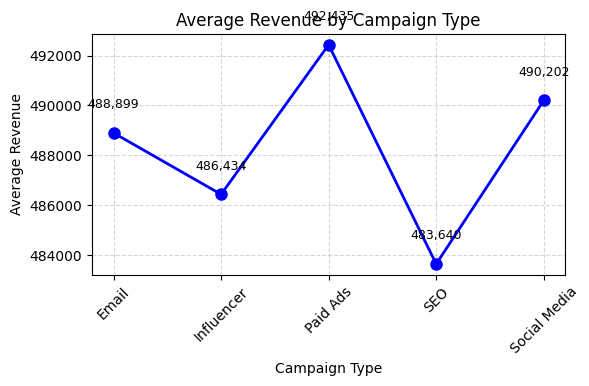

In [21]:
# Average revenue by campaign type
campaign_revenue = df.groupby('Campaign_Type')['Revenue'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(campaign_revenue['Campaign_Type'],  # X axis
         campaign_revenue['Revenue'],         # Y axis
         marker='o',        # Shows a dot at each point
         linewidth=2,        # Line thickness
         color='blue',       # Line color
         markersize=8)       # Size of the dots

# Add value labels on each point
for i, row in campaign_revenue.iterrows():
    plt.text(row['Campaign_Type'],           # X position
             row['Revenue'] + 1000,          # Y position (slightly above dot)
             f'{row["Revenue"]:,.0f}',       # Value to show
             ha='center',                    # Center align
             fontsize=9)

plt.title('Average Revenue by Campaign Type')
plt.xticks(rotation=45)
plt.ylabel('Average Revenue')
plt.xlabel('Campaign Type')
plt.grid(True, linestyle='--', alpha=0.5)   # Adds light grid lines
plt.tight_layout()
plt.show()

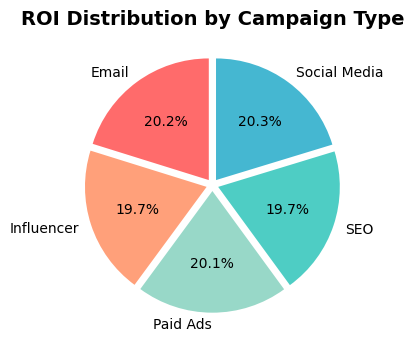

In [22]:
campaign_roi = df.groupby('Campaign_Type')['ROI'].mean().reset_index()

plt.figure(figsize=(4,4))
plt.pie(campaign_roi['ROI'],
        labels=campaign_roi['Campaign_Type'],
        autopct='%1.1f%%',      # Shows percentage on each slice
        startangle=90,           # Start from top
        colors=['#ff6b6b','#ffa07a','#98d8c8','#4ecdc4','#45b7d1'],
        explode=[0.05]*5)        # Slightly separate each slice

plt.title('ROI Distribution by Campaign Type', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Define all channel columns
channel_cols = ['C_U_Email', 'C_U_Facebook', 'C_U_Google',
                'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube']

# Calculate average ROI for each channel
channel_roi = {}
for ch in channel_cols:
    # Filter only rows where that channel was used (value = 1)
    channel_roi[ch] = df[df[ch] == 1]['ROI'].mean()

# Convert to DataFrame for easy plotting
channel_roi_df = pd.DataFrame(list(channel_roi.items()),
                               columns=['Channel', 'Avg_ROI'])

# Clean channel names for display (remove C_U_ prefix)
channel_roi_df['Channel'] = channel_roi_df['Channel'].str.replace('C_U_', '')

# Sort from highest to lowest
channel_roi_df = channel_roi_df.sort_values('Avg_ROI', ascending=False)

print(channel_roi_df)

     Channel      Avg_ROI
0      Email  5941.028831
3  Instagram  5927.310532
2     Google  5887.339376
1   Facebook  5861.024816
4   WhatsApp  5857.849994
5    YouTube  5827.307751


In [24]:
channel_cols = ['C_U_Email', 'C_U_Facebook', 'C_U_Google',
                'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube']

# Calculate multiple metrics together
channel_stats = []
for ch in channel_cols:
    filtered = df[df[ch] == 1]
    channel_stats.append({
        'Channel': ch.replace('C_U_', ''),
        'Avg_ROI': filtered['ROI'].mean(),
        'Avg_Revenue': filtered['Revenue'].mean(),
        'Avg_Clicks': filtered['Clicks'].mean(),
        'Profit_Rate': filtered['Profit_Flag'].mean() * 100
    })

stats_df = pd.DataFrame(channel_stats)
print(stats_df.round(2))

     Channel  Avg_ROI  Avg_Revenue  Avg_Clicks  Profit_Rate
0      Email  5941.03    490339.22     4657.40        95.04
1   Facebook  5861.02    488455.92     4653.01        95.05
2     Google  5887.34    487842.25     4618.60        95.12
3  Instagram  5927.31    490927.17     4655.29        94.94
4   WhatsApp  5857.85    488183.81     4648.44        95.10
5    YouTube  5827.31    486195.23     4647.96        95.01


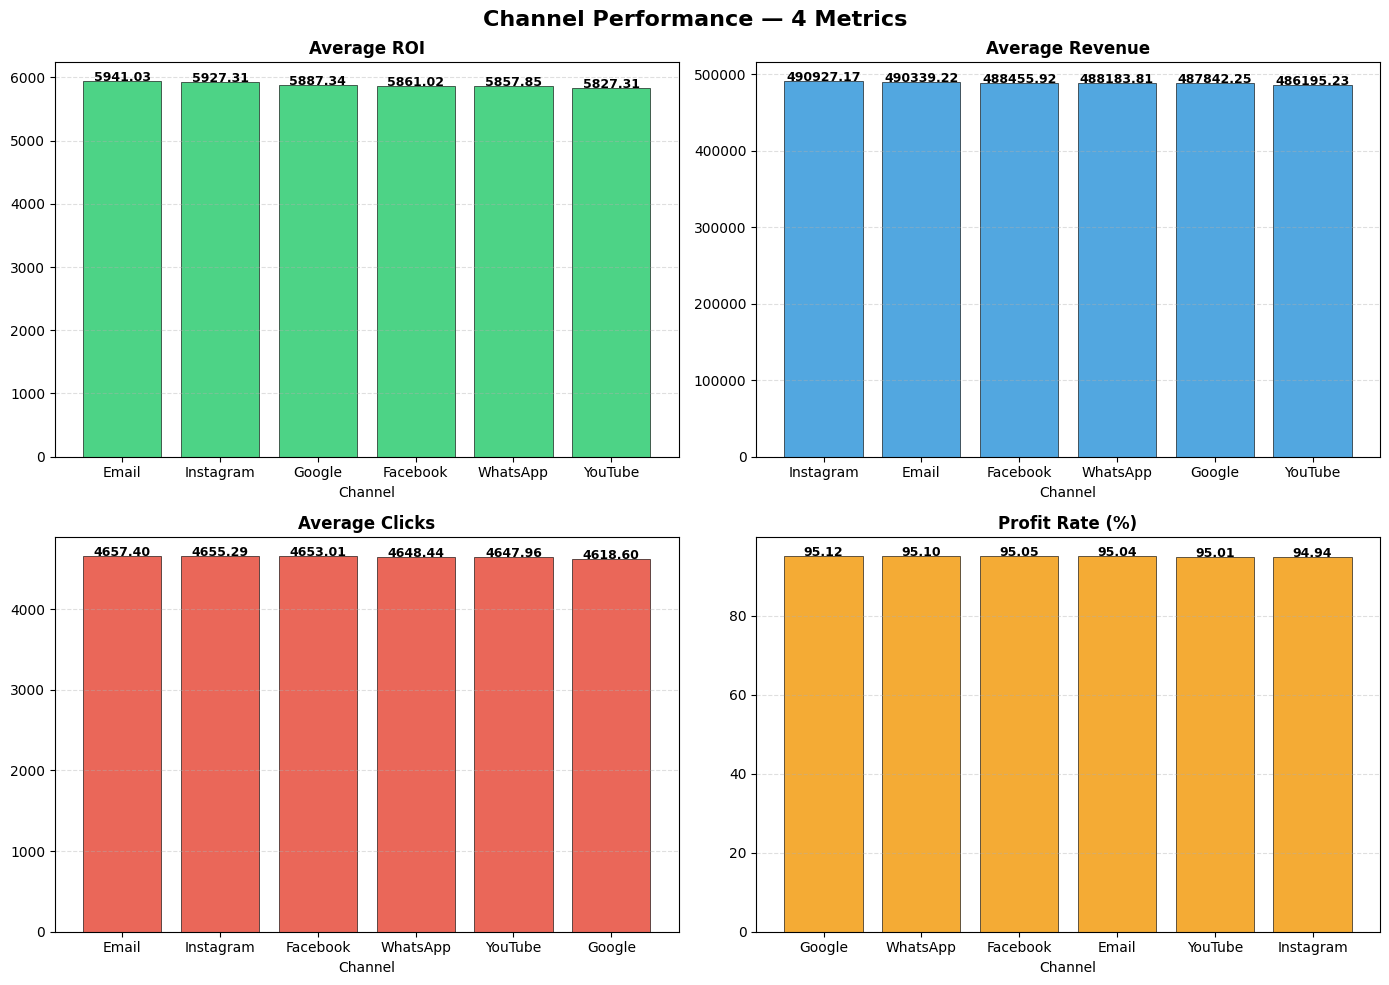

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Channel Performance — 4 Metrics',
             fontsize=16, fontweight='bold')

metrics = ['Avg_ROI', 'Avg_Revenue', 'Avg_Clicks', 'Profit_Rate']
titles  = ['Average ROI', 'Average Revenue', 
           'Average Clicks', 'Profit Rate (%)']
colors  = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    row = i // 2      # 0,0,1,1
    col = i % 2       # 0,1,0,1

    sorted_df = stats_df.sort_values(metric, ascending=False)

    bars = axes[row][col].bar(
        sorted_df['Channel'],
        sorted_df[metric],
        color=color,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.85
    )

    # Add value labels on top
    for bar, val in zip(bars, sorted_df[metric]):
        axes[row][col].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.2f}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    axes[row][col].set_title(title, fontweight='bold', fontsize=12)
    axes[row][col].set_xlabel('Channel')
    axes[row][col].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [26]:
df.columns

Index(['Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used',
       'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue',
       'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date', 'Brand', 'Channel_List', 'C_U_Email',
       'C_U_Facebook', 'C_U_Google', 'C_U_Instagram', 'C_U_WhatsApp',
       'C_U_YouTube', 'Profit_Flag'],
      dtype='str')

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ── Step 1: Encode categorical columns ──────────────────────────────
le = LabelEncoder()
df['Campaign_Type_enc']    = le.fit_transform(df['Campaign_Type'])
df['Target_Audience_enc']  = le.fit_transform(df['Target_Audience'])
df['Customer_Segment_enc'] = le.fit_transform(df['Customer_Segment'])

# ── Step 2: Define features (NO ROI — data leakage) ─────────────────
reg_features = [
    'Campaign_Type_enc', 'Target_Audience_enc', 'Customer_Segment_enc',
    'Duration', 'Impressions', 'Clicks', 'Leads',
    'Conversions', 'Acquisition_Cost', 'Engagement_Score',
    'Profit_Flag','ROI',
    'C_U_Email', 'C_U_Facebook', 'C_U_Google',
    'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube'
]

X_reg = df[reg_features]
y_reg = df['Revenue']

# ── Step 3: Train-Test Split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ── Step 4: Train & Evaluate Models ─────────────────────────────────
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MSE  : {mse:,.2f}")
    print(f"  RMSE : {np.sqrt(mse):,.2f}")
    print(f"  MAE  : {mean_absolute_error(y_test, y_pred):,.2f}")
    print(f"  R²   : {r2_score(y_test, y_pred):.4f}")


  Linear Regression
  MSE  : 49,981,892,641.32
  RMSE : 223,566.30
  MAE  : 151,227.66
  R²   : 0.7902

  Decision Tree
  MSE  : 506,996,099.45
  RMSE : 22,516.57
  MAE  : 6,127.76
  R²   : 0.9979

  Random Forest
  MSE  : 158,469,268.36
  RMSE : 12,588.46
  MAE  : 2,209.45
  R²   : 0.9993


In [28]:
import pickle

# Random Forest is the best regression model (R² = 0.9993)
best_reg_model = models['Random Forest']

with open('revenue_model.pkl', 'wb') as f:
    pickle.dump(best_reg_model, f)

print("✅ Revenue (Regression) model saved as revenue_model.pkl")

✅ Revenue (Regression) model saved as revenue_model.pkl


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── Features: NO ROI, NO Revenue — both cause leakage for classification ──
clf_features = [
    'Campaign_Type_enc', 'Target_Audience_enc', 'Customer_Segment_enc',
    'Duration', 'Impressions', 'Clicks', 'Leads',
    'Conversions', 'Acquisition_Cost', 'Engagement_Score',
    'C_U_Email', 'C_U_Facebook', 'C_U_Google',
    'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube'
]

X_clf = df[clf_features]
y_clf = df['Profit_Flag']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

clf_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in clf_models.items():
    model.fit(X_train_c, y_train_c)
    y_pred_c = model.predict(X_test_c)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {accuracy_score(y_test_c, y_pred_c):.4f}")
    print(f"  Precision : {precision_score(y_test_c, y_pred_c):.4f}")
    print(f"  Recall    : {recall_score(y_test_c, y_pred_c):.4f}")
    print(f"  F1-Score  : {f1_score(y_test_c, y_pred_c):.4f}")

c:\Users\Shyam\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



  Logistic Regression
  Accuracy  : 0.9485
  Precision : 0.9485
  Recall    : 1.0000
  F1-Score  : 0.9735

  Decision Tree
  Accuracy  : 0.8923
  Precision : 0.9487
  Recall    : 0.9371
  F1-Score  : 0.9429

  Random Forest
  Accuracy  : 0.9484
  Precision : 0.9485
  Recall    : 1.0000
  F1-Score  : 0.9735


In [30]:
# Random Forest will be the best classification model too
best_clf_model = clf_models['Random Forest']

with open('profit_model.pkl', 'wb') as f:
    pickle.dump(best_clf_model, f)

# Also save the feature lists and encoders — needed for Streamlit app
with open('reg_features.pkl', 'wb') as f:
    pickle.dump(reg_features, f)

with open('clf_features.pkl', 'wb') as f:
    pickle.dump(clf_features, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Profit (Classification) model saved as profit_model.pkl")
print("✅ Feature lists and encoder saved")

✅ Profit (Classification) model saved as profit_model.pkl
✅ Feature lists and encoder saved
